In [4]:
from datasets import load_dataset

dataset = load_dataset("anitamaxvim/jigsaw-toxic-comments")

df = dataset["train"].to_pandas()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:\n", df.head(3))
print("\nNull values:\n", df.isnull().sum())

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

d:\python_files\ann_project\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (159571, 7)

Columns: ['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Sample:
                                         comment_text  toxic  severe_toxic  \
0  Explanation\nWhy the edits made under my usern...      0             0   
1  D'aww! He matches this background colour I'm s...      0             0   
2  Hey man, I'm really not trying to edit war. It...      0             0   

   obscene  threat  insult  identity_hate  
0        0       0       0              0  
1        0       0       0              0  
2        0       0       0              0  

Null values:
 comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [5]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)

print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [6]:
print(label_pct)

toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30
dtype: float64


In [7]:
import os
path = '../data/raw/data.csv'
os.makedirs(os.path.dirname(path), exist_ok=True)
df.to_csv(path, index=False)

In [8]:
clean_ratio = (df[LABELS].sum(axis=1) == 0).mean() * 100
print(f"\nClean (non-toxic) comments: {clean_ratio:.1f}%")
print(f"Toxic comments (any label): {100 - clean_ratio:.1f}%")


Clean (non-toxic) comments: 89.8%
Toxic comments (any label): 10.2%



Text length stats:
 count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: text_len, dtype: float64

Comments with >128 tokens (approx): 20212 (12.7%)


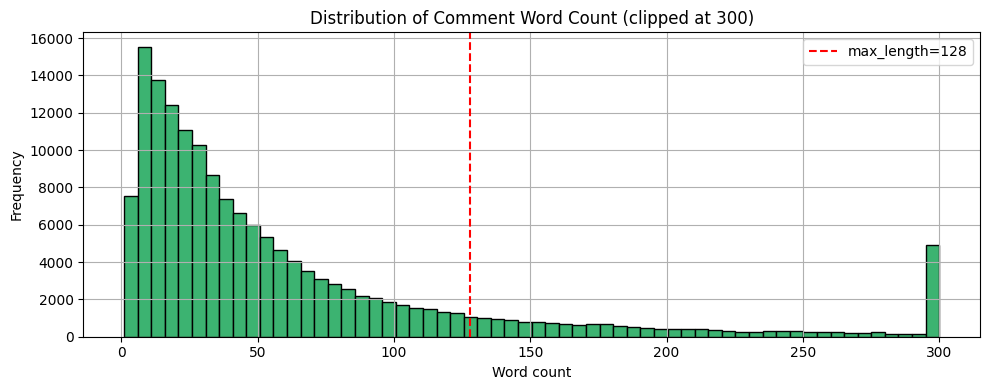

In [9]:
import matplotlib.pyplot as plt
df["text_len"] = df["comment_text"].str.split().str.len()

print("\nText length stats:\n", df["text_len"].describe().round(1))
print(f"\nComments with >128 tokens (approx): "
      f"{(df['text_len'] > 128).sum()} ({(df['text_len'] > 128).mean()*100:.1f}%)")

plt.figure(figsize=(10, 4))
df["text_len"].clip(upper=300).hist(bins=60, color="mediumseagreen", edgecolor="black")
plt.axvline(128, color="red", linestyle="--", label="max_length=128")
plt.title("Distribution of Comment Word Count (clipped at 300)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("text_length.png", dpi=150)
plt.show()

In [10]:
pos_counts = df[LABELS].sum()
neg_counts  = len(df) - pos_counts
pos_weight  = (neg_counts / pos_counts).round(2)

print("\npos_weight per label (for BCEWithLogitsLoss):")
print(pos_weight.to_dict())


pos_weight per label (for BCEWithLogitsLoss):
{'toxic': 9.43, 'severe_toxic': 99.04, 'obscene': 17.89, 'threat': 332.83, 'insult': 19.26, 'identity_hate': 112.57}


In [11]:
df[LABELS].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [12]:
neg_counts  = len(df) - pos_counts

In [13]:
neg_counts

toxic            144277
severe_toxic     157976
obscene          151122
threat           159093
insult           151694
identity_hate    158166
dtype: int64

In [14]:
pos_weight  = (neg_counts / pos_counts).round(2)

print("\npos_weight per label (for BCEWithLogitsLoss):")
print(pos_weight.to_dict())


pos_weight per label (for BCEWithLogitsLoss):
{'toxic': 9.43, 'severe_toxic': 99.04, 'obscene': 17.89, 'threat': 332.83, 'insult': 19.26, 'identity_hate': 112.57}


In [15]:
df['text_len']

0          43
1          17
2          42
3         113
4          13
         ... 
159566     47
159567     18
159568     12
159569     25
159570     36
Name: text_len, Length: 159571, dtype: int64

In [17]:
print(len(df[df['text_len'] <= 128]))

139359


In [18]:
df = dataset["test"].to_pandas()

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:\n", df.head(3))
print("\nNull values:\n", df.isnull().sum())

Shape: (63978, 7)

Columns: ['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Sample:
                                         comment_text  toxic  severe_toxic  \
0  Thank you for understanding. I think very high...      0             0   
1                   :Dear god this site is horrible.      0             0   
2  "::: Somebody will invariably try to add Relig...      0             0   

   obscene  threat  insult  identity_hate  
0        0       0       0              0  
1        0       0       0              0  
2        0       0       0              0  

Null values:
 comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [19]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)

print(label_counts)


toxic            6090
obscene          3691
insult           3427
identity_hate     712
severe_toxic      367
threat            211
dtype: int64


In [20]:
print(label_pct)

toxic            9.52
obscene          5.77
insult           5.36
identity_hate    1.11
severe_toxic     0.57
threat           0.33
dtype: float64
